# Inventory Recommendation (Prescriptive Analytics)
> **Tujuan**: Menggunakan hasil forecasting + inventory metrics untuk menghasilkan **rekomendasi restock** yang actionable.

In [1]:
## Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

PROCESSED = Path("../data/processed")
MODELS = Path("../models")

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.1f}".format)

## Load Data & Model

In [2]:
## Load inventory metrics (dari notebook inventory_analysis)
inventory_metrics = pd.read_csv(PROCESSED / "inventory_metrics.csv")
print("Inventory Metrics:")
print(inventory_metrics[["name", "current_stock", "avg_daily_sales", "days_remaining"]].to_string(index=False))

Inventory Metrics:
              name  current_stock  avg_daily_sales  days_remaining
           Chitato           15.0              6.1             2.5
Rokok Gudang Garam           30.0              4.0             7.5
    Shampo Pantene           24.0              3.3             7.2
         Telur 1kg           40.0              4.9             8.1
   Rokok Sampoerna           25.0              3.5             7.1
         Beras 5kg           39.0              5.0             7.8
        Taro Snack           58.0              5.4            10.8
    Sabun Lifebuoy           16.0              3.7             4.3
        Aqua 600ml           69.0              5.1            13.6
    Kopi Kapal Api           26.0              5.3             4.9
    Indomie Goreng          147.0              5.6            26.2


In [3]:
## Load trained forecasting model (dari notebook sales_forecasting)
bundle = joblib.load(MODELS / "sales_forecast.pkl")
model = bundle["model"]
feature_cols = bundle["feature_cols"]
model_name = bundle["model_name"]

print(f"Model: {model_name}")
print(f"Features: {feature_cols}")

Model: Random Forest
Features: ['day_of_week', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_mean_14']


In [4]:
## Load daily sales untuk recursive forecasting
daily_sales = pd.read_csv(PROCESSED / "daily_sales.csv", parse_dates=["date"])
daily_sales = daily_sales.sort_values("date").reset_index(drop=True)

print(f"Data periode: {daily_sales['date'].min().date()} s/d {daily_sales['date'].max().date()}")
print(f"Total hari: {len(daily_sales)}")

Data periode: 2026-05-29 s/d 2026-09-25
Total hari: 120


## Forecast Revenue 7 Hari Kedepan

In [5]:
## Recursive forecasting — prediksi hari per hari, output jadi input berikutnya
last_date = daily_sales["date"].max()
history = daily_sales["total_revenue"].values.tolist()

DAYS_AHEAD = 7

predictions = []
for i in range(1, DAYS_AHEAD + 1):
    future_date = last_date + pd.Timedelta(days=i)
    
    row = {
        "day_of_week": future_date.dayofweek,
        "is_weekend": int(future_date.dayofweek >= 5),
        "lag_1": history[-1],
        "lag_7": history[-7] if len(history) >= 7 else history[0],
        "rolling_mean_7": np.mean(history[-7:]),
        "rolling_mean_14": np.mean(history[-14:]) if len(history) >= 14 else np.mean(history[-7:]),
    }
    
    X = pd.DataFrame([row])[feature_cols]
    pred = max(float(model.predict(X)[0]), 0)
    
    predictions.append({"date": future_date, "predicted_revenue": round(pred)})
    history.append(pred)

forecast_df = pd.DataFrame(predictions)
print("Prediksi Revenue 7 Hari ke Depan:")
print(forecast_df.to_string(index=False))
print(f"\nTotal prediksi: Rp{forecast_df['predicted_revenue'].sum():,.0f}")
print(f"Rata-rata/hari: Rp{forecast_df['predicted_revenue'].mean():,.0f}")

Prediksi Revenue 7 Hari ke Depan:
      date  predicted_revenue
2026-09-26             904700
2026-09-27             899280
2026-09-28             967633
2026-09-29             914238
2026-09-30             776889
2026-10-01             815404
2026-10-02             826914

Total prediksi: Rp6,105,058
Rata-rata/hari: Rp872,151


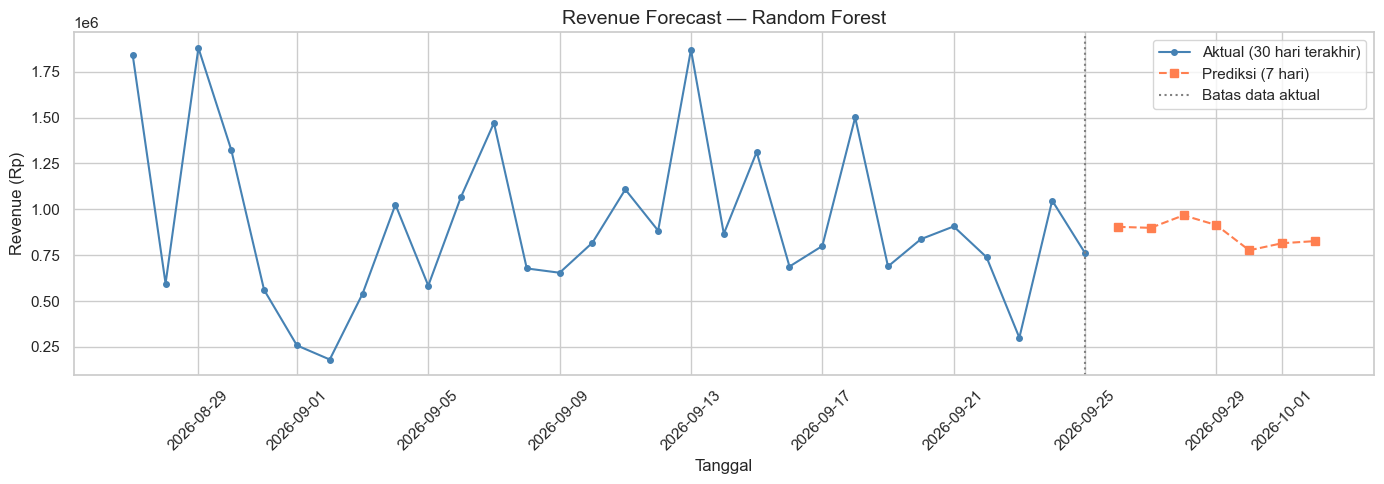

In [6]:
## Visualisasi forecast vs historical
fig, ax = plt.subplots(figsize=(14, 5))

recent = daily_sales.tail(30)
ax.plot(recent["date"], recent["total_revenue"], marker="o", markersize=4, 
        label="Aktual (30 hari terakhir)", color="steelblue")
ax.plot(forecast_df["date"], forecast_df["predicted_revenue"], marker="s", markersize=6,
        label="Prediksi (7 hari)", color="coral", linestyle="--")
ax.axvline(last_date, color="gray", linestyle=":", label="Batas data aktual")

ax.set_title(f"Revenue Forecast — {model_name}", fontsize=14)
ax.set_xlabel("Tanggal")
ax.set_ylabel("Revenue (Rp)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../docs/screenshots/forecast_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Rekomendasi Restok

In [7]:
## Hitung kebutuhan restock berdasarkan demand forecast + current stock
SAFETY_FACTOR = 1.3  # buffer 30% untuk antisipasi lonjakan

restock_df = inventory_metrics.copy()
restock_df["demand_7d"] = restock_df["avg_daily_sales"] * 7 * SAFETY_FACTOR
restock_df["restock_qty"] = (restock_df["demand_7d"] - restock_df["current_stock"]).clip(lower=0).round(0).astype(int)

# Urgency level
def get_urgency(row):
    dr = row["days_remaining"]
    if pd.isna(dr) or dr < 3:
        return "KRITIS"
    elif dr < 7:
        return "SEGERA"
    elif dr < 14:
        return "PERLU"
    return "AMAN"

restock_df["urgency"] = restock_df.apply(get_urgency, axis=1)

# Sort by urgency
urgency_order = {"KRITIS": 0, "SEGERA": 1, "PERLU": 2, "AMAN": 3}
restock_df["urgency_rank"] = restock_df["urgency"].map(urgency_order)
restock_df = restock_df.sort_values("urgency_rank")

print("Rekomendasi Restock (7 hari ke depan):")
display_cols = ["name", "current_stock", "avg_daily_sales", "days_remaining", "demand_7d", "restock_qty", "urgency"]
print(restock_df[display_cols].to_string(index=False))

Rekomendasi Restock (7 hari ke depan):
              name  current_stock  avg_daily_sales  days_remaining  demand_7d  restock_qty urgency
           Chitato           15.0              6.1             2.5       55.3           40  KRITIS
    Sabun Lifebuoy           16.0              3.7             4.3       33.5           18  SEGERA
    Kopi Kapal Api           26.0              5.3             4.9       48.1           22  SEGERA
Rokok Gudang Garam           30.0              4.0             7.5       36.3            6   PERLU
    Shampo Pantene           24.0              3.3             7.2       30.3            6   PERLU
         Telur 1kg           40.0              4.9             8.1       44.9            5   PERLU
   Rokok Sampoerna           25.0              3.5             7.1       32.2            7   PERLU
         Beras 5kg           39.0              5.0             7.8       45.4            6   PERLU
        Taro Snack           58.0              5.4            10.8    

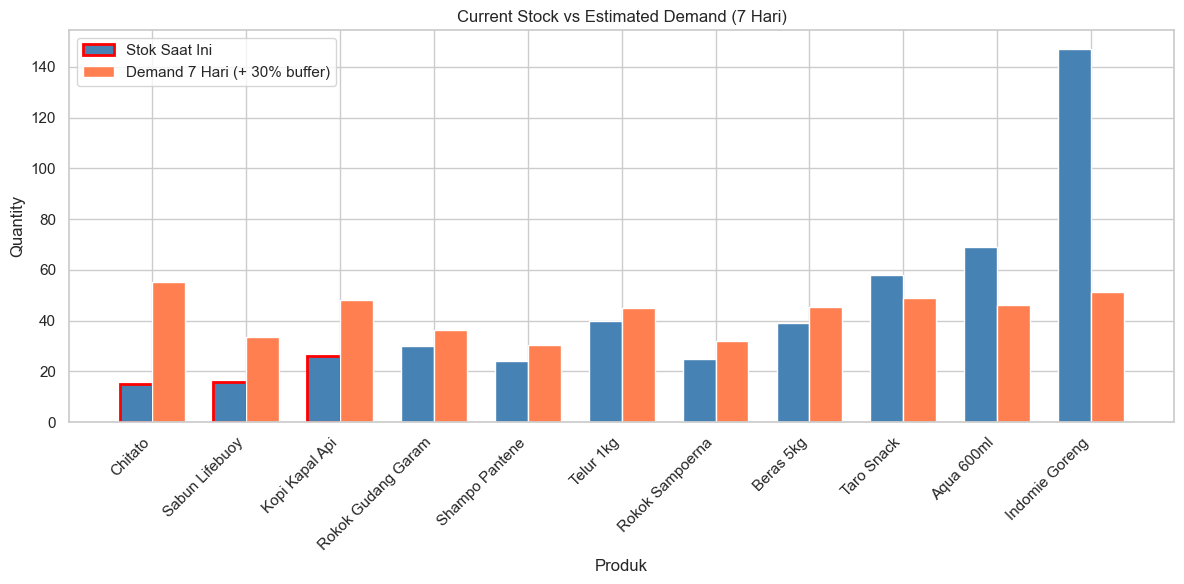

In [8]:
## Visualisasi: Current Stock vs Demand 7 hari
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(restock_df))
width = 0.35

bars1 = ax.bar(x - width/2, restock_df["current_stock"], width, label="Stok Saat Ini", color="steelblue")
bars2 = ax.bar(x + width/2, restock_df["demand_7d"], width, label="Demand 7 Hari (+ 30% buffer)", color="coral")

for i, (_, row) in enumerate(restock_df.iterrows()):
    if row["urgency"] in ("KRITIS", "SEGERA"):
        ax.get_children()[i].set_edgecolor("red")
        ax.get_children()[i].set_linewidth(2)

ax.set_xlabel("Produk")
ax.set_ylabel("Quantity")
ax.set_title("Current Stock vs Estimated Demand (7 Hari)")
ax.set_xticks(x)
ax.set_xticklabels(restock_df["name"], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/screenshots/restock_recommendation.png", dpi=150, bbox_inches="tight")
plt.show()

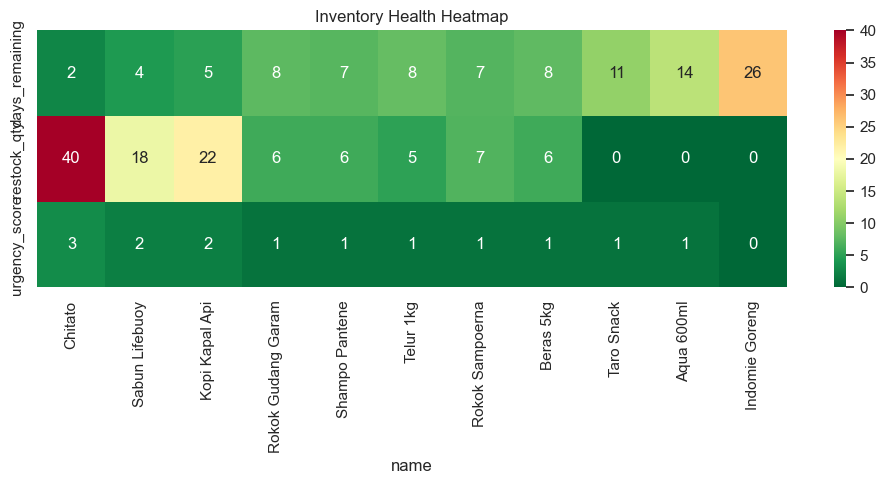

In [9]:
## Heatmap: Urgency per produk
fig, ax = plt.subplots(figsize=(10, 5))

urgency_colors = {"KRITIS": 3, "SEGERA": 2, "PERLU": 1, "AMAN": 0}
heatmap_data = restock_df.set_index("name")[["days_remaining", "restock_qty"]].copy()
heatmap_data["urgency_score"] = restock_df["urgency"].map(urgency_colors).values

sns.heatmap(
    heatmap_data.T, 
    annot=True, fmt=".0f", cmap="RdYlGn_r",
    xticklabels=restock_df["name"].values,
    ax=ax
)
ax.set_title("Inventory Health Heatmap")
plt.tight_layout()
plt.show()

## Summary

In [10]:
kritis = restock_df[restock_df["urgency"] == "KRITIS"]
segera = restock_df[restock_df["urgency"] == "SEGERA"]
perlu_restock = restock_df[restock_df["restock_qty"] > 0]

print("=" * 50)
print("RINGKASAN REKOMENDASI RESTOCK")
print("=" * 50)
print(f"Total produk dianalisis  : {len(restock_df)}")
print(f"Produk KRITIS            : {len(kritis)}")
print(f"Produk SEGERA            : {len(segera)}")
print(f"Total perlu restock      : {len(perlu_restock)}")
print(f"\nEstimasi total demand 7 hari : Rp{forecast_df['predicted_revenue'].sum():,.0f}")
print()

if len(kritis) > 0:
    print("Produk KRITIS (harus beli hari ini):")
    for _, r in kritis.iterrows():
        print(f"  - {r['name']}: stok {r['current_stock']}, restock {int(r['restock_qty'])} unit")

if len(segera) > 0:
    print("\nProduk SEGERA (beli dalam 2-3 hari):")
    for _, r in segera.iterrows():
        print(f"  - {r['name']}: stok {r['current_stock']}, sisa ~{r['days_remaining']:.0f} hari")

RINGKASAN REKOMENDASI RESTOCK
Total produk dianalisis  : 11
Produk KRITIS            : 1
Produk SEGERA            : 2
Total perlu restock      : 8

Estimasi total demand 7 hari : Rp6,105,058

Produk KRITIS (harus beli hari ini):
  - Chitato: stok 15.0, restock 40 unit

Produk SEGERA (beli dalam 2-3 hari):
  - Sabun Lifebuoy: stok 16.0, sisa ~4 hari
  - Kopi Kapal Api: stok 26.0, sisa ~5 hari
